In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

# Load the dataset
faces = fetch_olivetti_faces()
X = faces.data
print(f"Dataset loaded with {X.shape[0]} images, each with {X.shape[1]} pixels.")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
Dataset loaded with 400 images, each with 4096 pixels.


Displaying original faces:


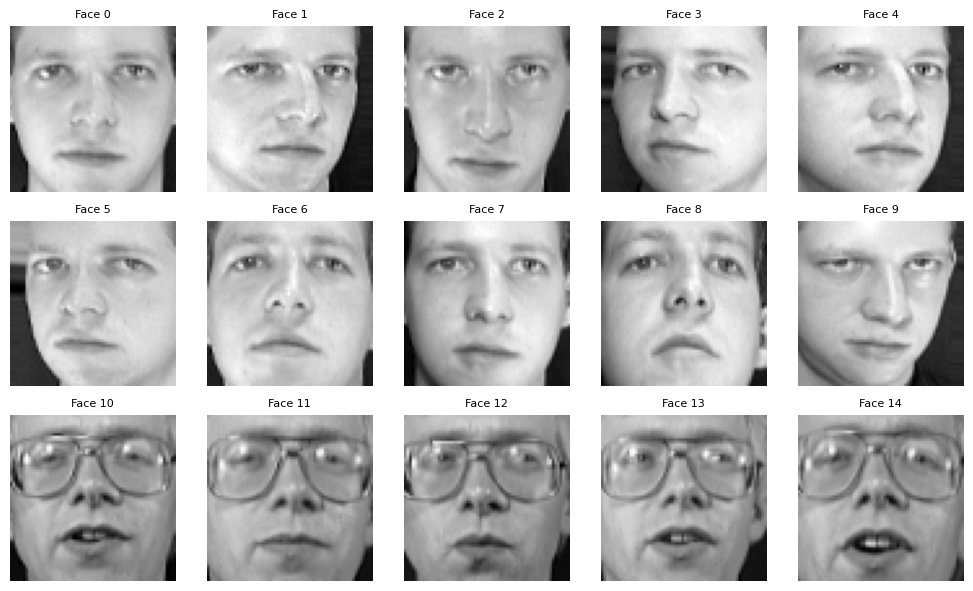

In [2]:
def plot_faces(images, titles=None, n_row=3, n_col=5):
    plt.figure(figsize=(2 * n_col, 2 * n_row))
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        # Reshape flat 4096 vector back to 64x64 image
        plt.imshow(images[i].reshape(64, 64), cmap='gray')
        if titles is not None:
            plt.title(titles[i], fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display the first 15 original faces
print("Displaying original faces:")
plot_faces(X[:15], [f"Face {i}" for i in range(15)])

In [3]:
def principal_component_analysis(X, l):
    # 1. Mean centering
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean
    
    # 2. Calculate covariance matrix
    sigma = X_centered.T.dot(X_centered) / (len(X_centered) - 1)
    
    # 3. Compute eigenvalues (a) and eigenvectors (w)
    a, w = np.linalg.eig(sigma)
    
    # 4. Sort eigenvectors by eigenvalues in descending order
    sorted_indx = np.argsort(-a)
    
    # 5. Select top 'l' components
    top_eigenvectors = w[:, sorted_indx[0:l]]
    X_new = X_centered.dot(top_eigenvectors)
    
    return X_new, top_eigenvectors, a[sorted_indx[0:l]]

# Run PCA to extract 20 components
print("Running PCA...")
%time faces_reduced, W, lambdas = principal_component_analysis(X, 20)

Running PCA...
CPU times: user 2min 35s, sys: 621 ms, total: 2min 35s
Wall time: 43.6 s


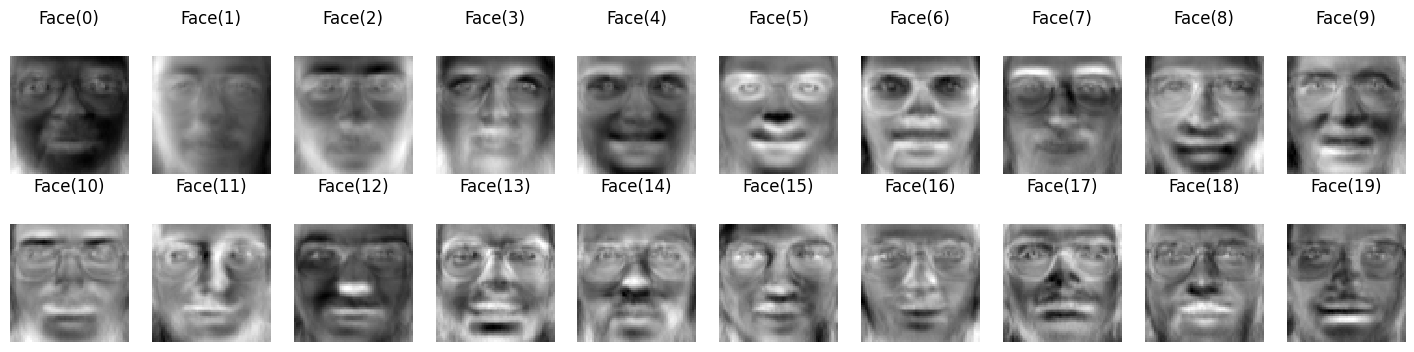

In [4]:
# Visualizing the first 20 Eigenfaces (Principal Components)
fig = plt.figure(figsize=(18, 4))
plt.gray()
for i in range(0, 20):
    ax = fig.add_subplot(2, 10, i + 1)
    # W represents the principal components
    ax.matshow(W.real[:, i].reshape((64, 64)))
    plt.title("Face(" + str(i) + ")")
    plt.box(False)
    plt.axis("off")
plt.show()

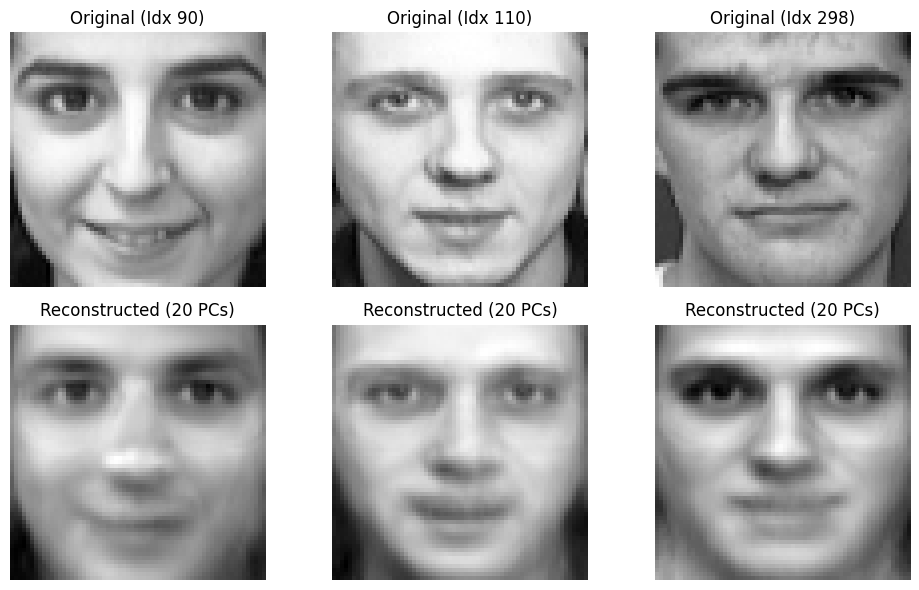

In [5]:
# Select 3 random indices to compare original vs reconstruction
random_indices = np.random.choice(len(X), 3, replace=False)
mean_face = np.mean(X, axis=0)

plt.figure(figsize=(10, 6))
for i, idx in enumerate(random_indices):
    # Display Original Face
    plt.subplot(2, 3, i + 1)
    plt.imshow(X[idx].reshape(64, 64), cmap='gray')
    plt.title(f"Original (Idx {idx})")
    plt.axis('off')
    
    # Reconstruct the face: Mean + (Weights * Components)
    reconstruction = mean_face + W.real.dot(faces_reduced[idx].real)
    
    # Display Reconstructed Face
    plt.subplot(2, 3, i + 4)
    plt.imshow(reconstruction.reshape(64, 64), cmap='gray')
    plt.title("Reconstructed (20 PCs)")
    plt.axis('off')

plt.tight_layout()
plt.show()

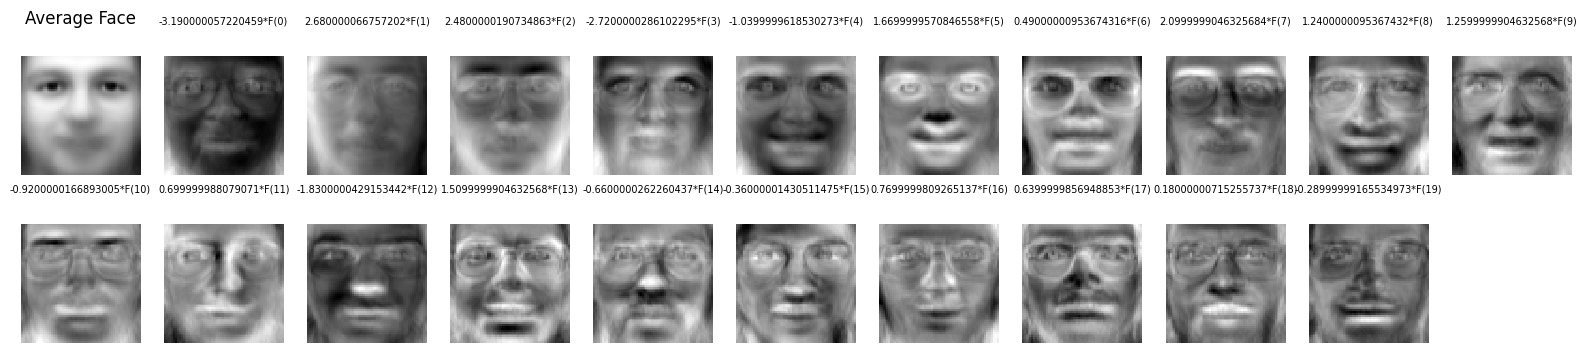

In [6]:
# Select a random sample to visualize the math process
sample_indx = np.random.randint(0, len(X))

fig = plt.figure(figsize=(20, 4))
plt.gray()

# Display Average Face
ax = fig.add_subplot(2, 11, 1)
ax.matshow(mean_face.reshape((64, 64)))
plt.title("Average Face")
plt.axis("off")

# Display first 20 weighted components contributing to this face
for i in range(0, 20):
    ax = fig.add_subplot(2, 11, i + 2)
    ax.matshow(W.real[:, i].reshape((64, 64)))
    # Show weight contribution
    weight = round(faces_reduced[sample_indx][i].real, 2)
    plt.title(f"{weight}*F({i})", fontsize=7)
    plt.box(False)
    plt.axis("off")

plt.show()

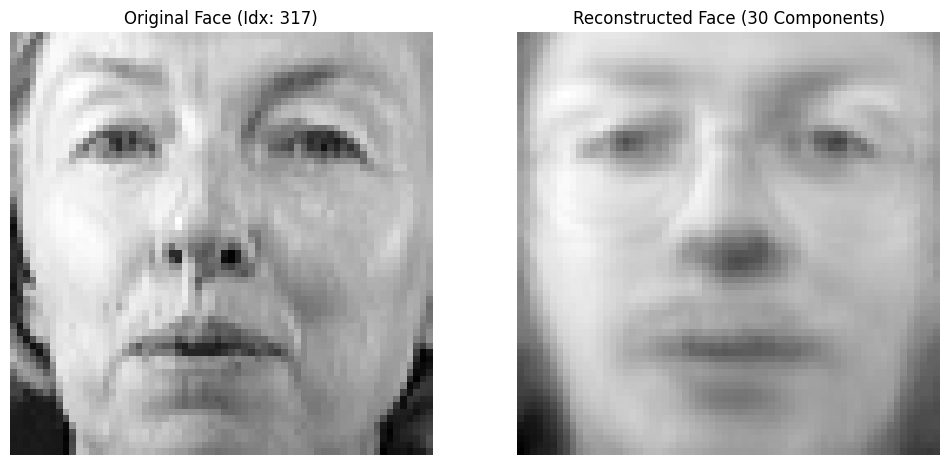

In [7]:
# 5. Visualize Results (30 Components)
plt.figure(figsize=(12, 6))

# Display the Original
plt.subplot(1, 2, 1)
plt.imshow(X[sample_indx].reshape(64, 64), cmap='gray')
plt.title(f"Original Face (Idx: {sample_indx})")
plt.axis('off')

# Reconstruction logic: Mean + (Weights dot Components)
reconstruction = mean_face + W.real.dot(faces_reduced[sample_indx].real)

# Display the Reconstructed version
plt.subplot(1, 2, 2)
plt.imshow(reconstruction.reshape(64, 64), cmap='gray')
plt.title("Reconstructed Face (30 Components)")
plt.axis('off')

plt.show()





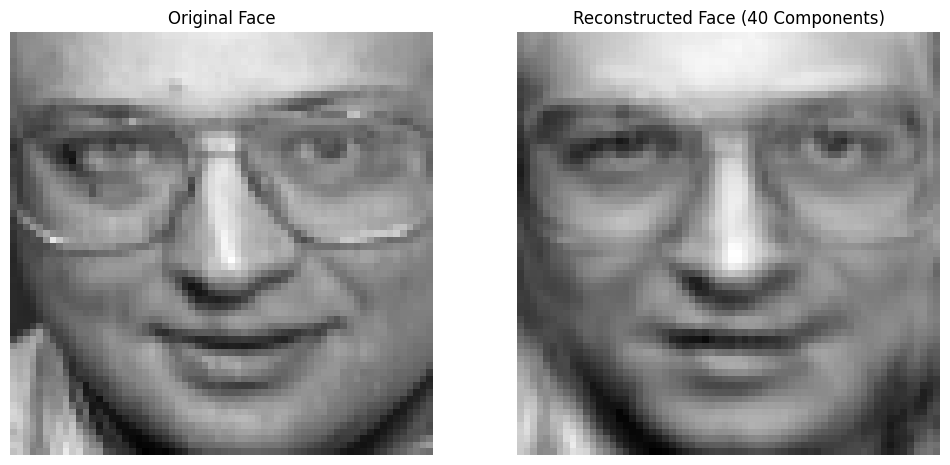

In [8]:
# Run PCA again, this time extracting 40 components
faces_reduced, W, lambdas = principal_component_analysis(X, 40)

sample_indx = np.random.randint(0, len(X))
mean_face = np.mean(X, axis=0)

plt.figure(figsize=(12, 6))

# Original Face
plt.subplot(1, 2, 1)
plt.imshow(X[sample_indx].reshape(64, 64), cmap='gray')
plt.title("Original Face")
plt.axis('off')

# Reconstruction using 40 components
reconstruction = mean_face + W.real.dot(faces_reduced[sample_indx].real)

# Reconstructed Face
plt.subplot(1, 2, 2)
plt.imshow(reconstruction.reshape(64, 64), cmap='gray')
plt.title("Reconstructed Face (40 Components)")
plt.axis('off')

plt.show()

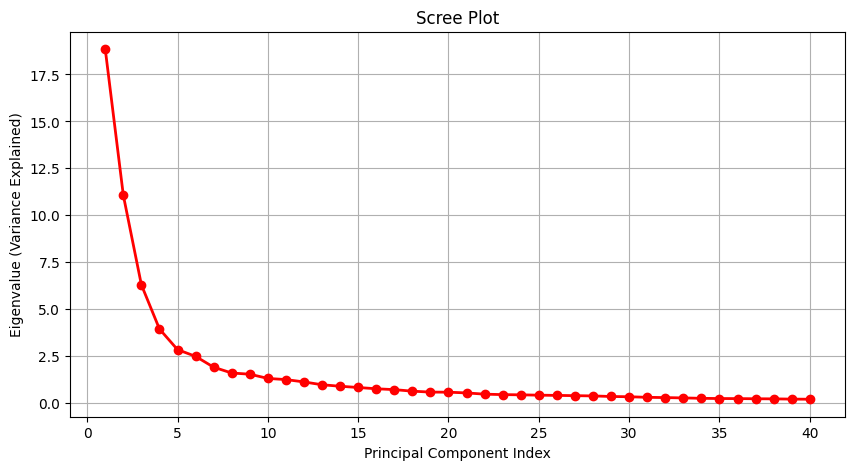

In [9]:
# Visualize the importance of each component
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(lambdas)) + 1, lambdas.real, 'ro-', linewidth=2)
plt.title('Scree Plot')
plt.xlabel('Principal Component Index')
plt.ylabel('Eigenvalue (Variance Explained)')
plt.grid(True)
plt.show()

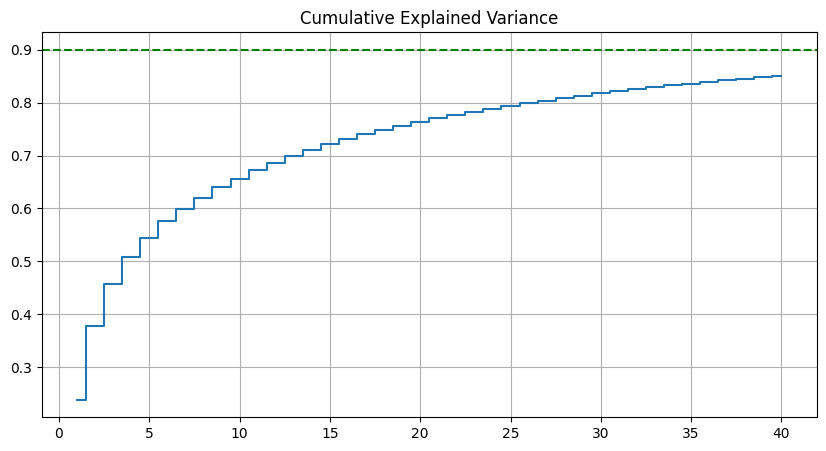

In [10]:
# --- Fixed Analysis Section ---

# 1. Calculate sigma outside the function so the notebook can "see" it
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean
sigma = X_centered.T.dot(X_centered) / (len(X_centered) - 1)

# 2. Now this will work!
all_eigenvalues, _ = np.linalg.eig(sigma)
total_var = np.sum(all_eigenvalues.real)

# 3. Calculate cumulative percentage
cumulative_variance = np.cumsum(lambdas.real) / total_var

# --- Now run your plotting code below ---
plt.figure(figsize=(10, 5))
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid')
plt.axhline(y=0.9, color='g', linestyle='--')
plt.title('Cumulative Explained Variance')
plt.grid(True)
plt.show()

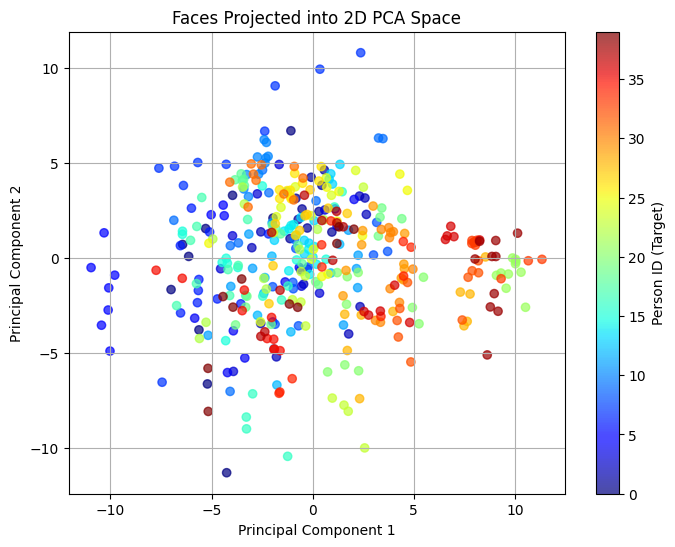

In [11]:
# Scatter plot of the first two principal components
plt.figure(figsize=(8, 6))
plt.scatter(faces_reduced.real[:, 0], faces_reduced.real[:, 1], c=faces.target, cmap='jet', alpha=0.7)
plt.colorbar(label='Person ID (Target)')
plt.title('Faces Projected into 2D PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()